In [19]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset 2 - Detailed URL Parsing (112 features)

In [20]:
df = pd.read_csv("dataset/dataset2.csv")
print(df.shape)
print(df["phishing"].value_counts())

(88647, 112)
phishing
0    58000
1    30647
Name: count, dtype: int64


In [21]:
X = df.drop(columns=["phishing"])
y = df["phishing"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

stnd = StandardScaler()
X_train_s = stnd.fit_transform(X_train)
X_test_s  = stnd.transform(X_test)

print(X_train.shape, X_test.shape)

(70917, 111) (17730, 111)


# Simple Decision Tree

In [33]:
dt_simple = DecisionTreeClassifier(max_depth=5, random_state=0)
dt_simple.fit(X_train_s, y_train)
y_pred_simple = dt_simple.predict(X_test_s)

print(classification_report(y_test, y_pred_simple, target_names=["Legitimate", "Phishing"]))
cm = confusion_matrix(y_test, y_pred_simple)
print(cm)

              precision    recall  f1-score   support

  Legitimate       0.97      0.93      0.95     11600
    Phishing       0.88      0.94      0.91      6130

    accuracy                           0.93     17730
   macro avg       0.92      0.94      0.93     17730
weighted avg       0.94      0.93      0.93     17730

[[10779   821]
 [  358  5772]]


# Tuned Decision Tree

In [23]:
grid = {"max_depth": np.arange(5, 35, 1)}
dt_cv = GridSearchCV(DecisionTreeClassifier(random_state=0), grid, cv=3, return_train_score=True)
dt_cv.fit(X_train_s, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 5, 6..., 32, 33, 34])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold an

In [24]:
print("Best params:", dt_cv.best_params_)
print("Train score:", dt_cv.best_estimator_.score(X_train_s, y_train))
print("Val score:  ", dt_cv.best_score_)
print("Test score: ", dt_cv.best_estimator_.score(X_test_s, y_test))

y_pred_tuned = dt_cv.best_estimator_.predict(X_test_s)
print()
print(classification_report(y_test, y_pred_tuned, target_names=["Legitimate", "Phishing"]))

cm = confusion_matrix(y_test, y_pred_tuned)
print(cm)

Best params: {'max_depth': np.int64(13)}
Train score: 0.9805688339890294
Val score:   0.9546230099976029
Test score:  0.9583756345177665

              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97     11600
    Phishing       0.93      0.95      0.94      6130

    accuracy                           0.96     17730
   macro avg       0.95      0.96      0.95     17730
weighted avg       0.96      0.96      0.96     17730

[[11189   411]
 [  327  5803]]


# Feature Importance

Top 15 features:
directory_length          0.6445
time_domain_activation    0.1118
qty_plus_file             0.0459
asn_ip                    0.0272
qty_dot_domain            0.0240
length_url                0.0238
time_response             0.0214
ttl_hostname              0.0160
time_domain_expiration    0.0098
qty_nameservers           0.0082
domain_length             0.0079
qty_hyphen_directory      0.0077
qty_slash_url             0.0070
qty_mx_servers            0.0063
qty_ip_resolved           0.0060
dtype: float64


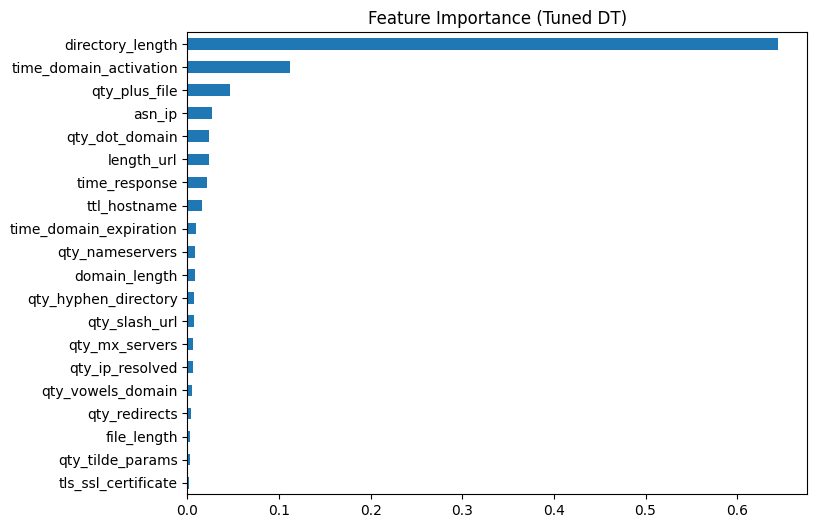

In [25]:
importances = pd.Series(dt_cv.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 features:")
print(importances.head(15).round(4))
importances.head(20).plot.barh(figsize=(8, 6), title="Feature Importance (Tuned DT)").invert_yaxis()

# PCA

<Axes: title={'center': 'Cumulative PVE'}, xlabel='Component', ylabel='Cumulative Explained Variance'>

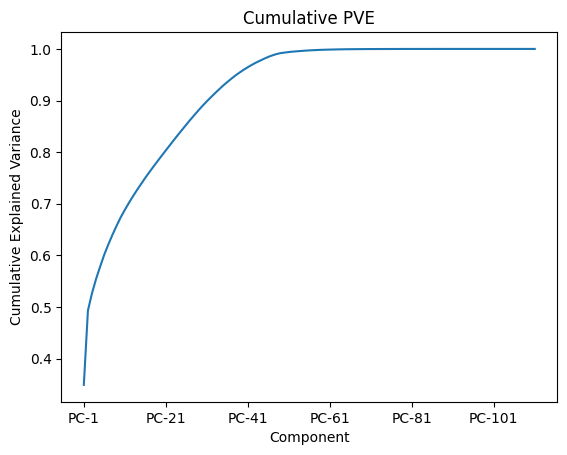

In [26]:
n_comp = X_train_s.shape[1]
cols = ["PC-" + str(i + 1) for i in range(n_comp)]

pca_full = PCA(n_components=n_comp)
pca_full.fit(X_train_s)
PVE = pd.Series(pca_full.explained_variance_ratio_, index=cols)

cumulative = PVE.cumsum()
cumulative.plot(title="Cumulative PVE", xlabel="Component", ylabel="Cumulative Explained Variance")

In [27]:
component_options = [10, 20, 30, 40, 50, 60, 80, n_comp]
pca_results = []

for n in component_options:
    pca_temp = PCA(n_components=n)
    X_pca_temp = pca_temp.fit_transform(X_train_s)
    scores = cross_val_score(DecisionTreeClassifier(random_state=0), X_pca_temp, y_train, cv=3, scoring="accuracy")
    pca_results.append({"num_components": n, "accuracy": scores.mean()})

pca_results = pd.DataFrame(pca_results)
print(pca_results)
best_n = int(pca_results.loc[pca_results["accuracy"].idxmax(), "num_components"])
print("Best n_components:", best_n)

   num_components  accuracy
0              10  0.930524
1              20  0.933190
2              30  0.934303
3              40  0.935770
4              50  0.937279
5              60  0.936137
6              80  0.935516
7             111  0.936193
Best n_components: 50


In [28]:
pca_best = PCA(n_components=best_n)
X_train_pca = pca_best.fit_transform(X_train_s)
X_test_pca  = pca_best.transform(X_test_s)

dt_pca_cv = GridSearchCV(DecisionTreeClassifier(random_state=0), grid, cv=3, return_train_score=True)
dt_pca_cv.fit(X_train_pca, y_train)

y_pred_pca = dt_pca_cv.best_estimator_.predict(X_test_pca)

print("Tuned DT + PCA")
print("Best params:", dt_pca_cv.best_params_)
print("Train score:", dt_pca_cv.best_estimator_.score(X_train_pca, y_train))
print("Val score:  ", dt_pca_cv.best_score_)
print("Test score: ", dt_pca_cv.best_estimator_.score(X_test_pca, y_test))
print()
print(classification_report(y_test, y_pred_pca, target_names=["Legitimate", "Phishing"]))

cm = confusion_matrix(y_test, y_pred_pca)
print(cm)

Tuned DT + PCA
Best params: {'max_depth': np.int64(12)}
Train score: 0.9787075031374706
Val score:   0.9438780546272403
Test score:  0.9487309644670051

              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96     11600
    Phishing       0.92      0.93      0.93      6130

    accuracy                           0.95     17730
   macro avg       0.94      0.94      0.94     17730
weighted avg       0.95      0.95      0.95     17730

[[11139   461]
 [  448  5682]]


# Ridge Classifier

In [34]:
rc_simple = RidgeClassifier()
rc_simple.fit(X_train_s, y_train)
y_pred_rc = rc_simple.predict(X_test_s)

print("Simple Ridge Classifier")
print(classification_report(y_test, y_pred_rc, target_names=["Legitimate", "Phishing"]))
cm = confusion_matrix(y_test, y_pred_rc)
print(cm)

Simple Ridge Classifier
              precision    recall  f1-score   support

  Legitimate       0.97      0.89      0.93     11600
    Phishing       0.82      0.95      0.88      6130

    accuracy                           0.91     17730
   macro avg       0.90      0.92      0.91     17730
weighted avg       0.92      0.91      0.92     17730

[[10356  1244]
 [  284  5846]]


# Tuned Ridge Classifier

In [30]:
alphas = np.logspace(-3, 4, 30)
rc_cv = RidgeClassifierCV(alphas=alphas)
rc_cv.fit(X_train_s, y_train)

y_pred_rc_tuned = rc_cv.predict(X_test_s)

print("Tuned Ridge Classifier")
print("Best params:", rc_cv.alpha_)
print("Train score:", rc_cv.score(X_train_s, y_train))
print("Val score:  ", rc_cv.best_score_)
print("Test score:", rc_cv.score(X_test_s, y_test))
print()
print(classification_report(y_test, y_pred_rc_tuned, target_names=["Legitimate", "Phishing"]))

cm = confusion_matrix(y_test, y_pred_rc_tuned)
print(cm)

Tuned Ridge Classifier
Best params: 621.0169418915616
Train score: 0.9154081531931695
Val score:   -0.2836805050772161
Test score: 0.9120699379582629

              precision    recall  f1-score   support

  Legitimate       0.97      0.89      0.93     11600
    Phishing       0.82      0.95      0.88      6130

    accuracy                           0.91     17730
   macro avg       0.90      0.92      0.91     17730
weighted avg       0.92      0.91      0.91     17730

[[10327  1273]
 [  286  5844]]


# Ridge Classifier + PCA

In [31]:
rc_pca = RidgeClassifierCV(alphas=alphas)
rc_pca.fit(X_train_pca, y_train)
y_pred_rc_pca = rc_pca.predict(X_test_pca)

print("Tuned Ridge Classifier + PCA")
print("Best alpha:", rc_pca.alpha_)
print("Train score:", rc_cv.score(X_train_s, y_train))
print("Val score:  ", rc_cv.best_score_)
print("Test score:", rc_pca.score(X_test_pca, y_test))
print()
print(classification_report(y_test, y_pred_rc_pca, target_names=["Legitimate", "Phishing"]))

cm = confusion_matrix(y_test, y_pred_rc_pca)
print(cm)

Tuned Ridge Classifier + PCA
Best alpha: 1082.636733874054
Train score: 0.9154081531931695
Val score:   -0.2836805050772161
Test score: 0.910547095318669

              precision    recall  f1-score   support

  Legitimate       0.97      0.89      0.93     11600
    Phishing       0.82      0.95      0.88      6130

    accuracy                           0.91     17730
   macro avg       0.90      0.92      0.90     17730
weighted avg       0.92      0.91      0.91     17730

[[10290  1310]
 [  276  5854]]


# Summary

In [35]:
summary = pd.DataFrame({
    "Model": [
        "DT (simple, depth=5)",
        "DT (tuned)",
        "DT (tuned) + PCA",
        "Ridge (simple)",
        "Ridge (tuned)",
        "Ridge (tuned) + PCA",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_simple),
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_pca),
        accuracy_score(y_test, y_pred_rc),
        accuracy_score(y_test, y_pred_rc_tuned),
        accuracy_score(y_test, y_pred_rc_pca),
    ]
})
summary["Error"] = 1 - summary["Accuracy"]
summary["Accuracy"] = summary["Accuracy"]
print(summary.to_string(index=False))

               Model  Accuracy    Error
DT (simple, depth=5)  0.933503 0.066497
          DT (tuned)  0.958376 0.041624
    DT (tuned) + PCA  0.948731 0.051269
      Ridge (simple)  0.913818 0.086182
       Ridge (tuned)  0.912070 0.087930
 Ridge (tuned) + PCA  0.910547 0.089453
